In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier

In [ ]:

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, ROOT)

from src.split_data import split_data

cancerous = {"BCC", "SCC", "MEL"}

def make_features_labels(df, extra_drops=()):
    drops = ["img_id", "diagnostic", "Unnamed: 0", *extra_drops]
    features = df.drop(columns=drops, errors="ignore").select_dtypes(include="number")
    labels = np.where(df["diagnostic"].isin(cancerous), "cancerous", "non-cancerous")
    return features, labels

def make_forest(seed=6, n_estimators=200, max_depth=None):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced",
        random_state=seed,
    )

In [2]:
features_path = os.path.join(ROOT, "data", "features.csv")
splits_dir    = os.path.join(ROOT, "data", "splits")
train_df, val_df, test_df = split_data(features_path, 0.65, 0.20, 42, splits_dir)

print("diagnostic classes:", sorted(train_df["diagnostic"].unique()))
print("class counts (train):")
print(train_df["diagnostic"].value_counts())

diagnostic classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
class counts (train):
diagnostic
BCC    529
ACK    404
NEV    150
SEK    135
SCC    115
MEL     33
Name: count, dtype: int64


In [3]:
train_X, train_binary = make_features_labels(train_df)
val_X,   val_binary   = make_features_labels(val_df)
train_multi = train_df["diagnostic"].values

In [4]:
N = 20
binary_accs = []
multi_accs  = []

for seed in range(N):
    # train on binary labels directly
    forest = make_forest(seed)
    forest.fit(train_X, train_binary)
    binary_accs.append(forest.score(val_X, val_binary))

    # train on 6-class then collapse predictions to binary
    forest = make_forest(seed)
    forest.fit(train_X, train_multi)
    preds  = forest.predict(val_X)
    binary = np.where(pd.Series(preds).isin(cancerous), "cancerous", "non-cancerous")
    multi_accs.append((binary == val_binary).mean())

    print(f"seed {seed+1}/{N}: binary={binary_accs[-1]:.4f}  6-class={multi_accs[-1]:.4f}")

acc_df = pd.DataFrame({"binary": binary_accs, "6-class": multi_accs})

seed 1/20: binary=0.7786  6-class=0.7071
seed 2/20: binary=0.7476  6-class=0.7000
seed 3/20: binary=0.7500  6-class=0.7214
seed 4/20: binary=0.7310  6-class=0.6905
seed 5/20: binary=0.7476  6-class=0.7024
seed 6/20: binary=0.7476  6-class=0.7000
seed 7/20: binary=0.7500  6-class=0.6881
seed 8/20: binary=0.7452  6-class=0.7286
seed 9/20: binary=0.7500  6-class=0.6976
seed 10/20: binary=0.7524  6-class=0.7048
seed 11/20: binary=0.7476  6-class=0.7143
seed 12/20: binary=0.7405  6-class=0.6952
seed 13/20: binary=0.7381  6-class=0.6905
seed 14/20: binary=0.7429  6-class=0.6833
seed 15/20: binary=0.7405  6-class=0.7095
seed 16/20: binary=0.7500  6-class=0.7095
seed 17/20: binary=0.7500  6-class=0.6976
seed 18/20: binary=0.7357  6-class=0.7024
seed 19/20: binary=0.7476  6-class=0.7095
seed 20/20: binary=0.7548  6-class=0.7000


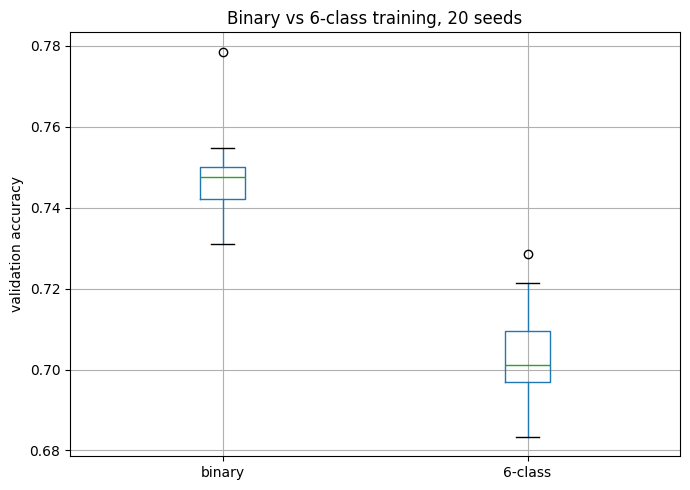

Binary vs 6-class fitting, n=20:
  binary   mean=0.7474  std=0.0095
  6-class  mean=0.7026  std=0.0111
  mean diff (binary - 6-class): +0.0448
  p-value: 0.000088


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
acc_df.boxplot(ax=ax)
ax.set_ylabel("validation accuracy")
ax.set_title(f"Binary vs 6-class training, {N} seeds")
plt.tight_layout()
plt.show()

diffs   = acc_df["binary"] - acc_df["6-class"]
stat, p = stats.wilcoxon(acc_df["binary"], acc_df["6-class"], zero_method="wilcox")

print(f"Binary vs 6-class fitting, n={N}:")
print(f"  binary   mean={acc_df['binary'].mean():.4f}  std={acc_df['binary'].std():.4f}")
print(f"  6-class  mean={acc_df['6-class'].mean():.4f}  std={acc_df['6-class'].std():.4f}")
print(f"  mean diff (binary - 6-class): {diffs.mean():+.4f}")
print(f"  p-value: {p:.6f}")